# HER2 Model Evaluation Script

This notebook evaluates trained HER2 classification models (ResNet-50 or EfficientNet-B0) by extracting patches directly from WSI files.

**Inputs**:
- Trained model checkpoint (.pth file)
- WSI metadata CSV with slide paths and HER2 status
- WSI files (.svs) with optional XML annotations for ROI filtering

**Outputs**:
- Evaluation metrics: Accuracy, Precision, Recall, F1-Score, AUC
- Confusion matrix and ROC curve
- Per-slide aggregated predictions

**Note**: Patches are extracted on-the-fly from WSI files during inference. ROI annotations (XML) are used if available to filter patches to tumor regions.

## 1. Setup and Imports

In [2]:
import sys
import os
from pathlib import Path

# Add parent directory to path
parent_dir = Path.cwd().parent
sys.path.insert(0, str(parent_dir))

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast
from torchvision import transforms

# Sklearn metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Project imports
from src.models.patch_classifier import PatchClassifier
from src.dataloader.wsi_reader import WSIReader
from src.preprocessing.roi_utils import parse_asap_xml, patch_in_roi, get_annotation_path
from src.utils.io import load_checkpoint
from src.utils.device import get_device

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Imports successful
PyTorch version: 2.9.1+cu128
CUDA available: True


## 2. Configuration

In [15]:
eval_config = {
    # Model configuration
    'checkpoint_path': r'C:\Users\tanth\Desktop\her2-attention-classifier\outputs\phase1\best_model.pth',  # Path to trained model
    'backbone': 'resnet50',  # 'resnet50' or 'efficientnet_b0'
    'num_classes': 2,
    
    # Data configuration
    'wsi_csv': r'C:\Users\tanth\Desktop\her2-attention-classifier\outputs\dataloader\wsi_paths.csv',  # WSI paths with HER2 status
    'patch_size': 512,  # Patch size to extract from WSI
    'stride': 512,  # Stride for patch extraction (224 = non-overlapping)
    'level': 0,  # Pyramid level to extract from (0 = highest resolution)
    'max_slides': None,  # Limit number of slides to process (None = all slides)
    'patches_per_slide': 20,  # Number of patches to sample per slide
    'random_seed': None,  # Seed for reproducible random sampling (None = different each run)
    
    # Inference configuration
    'batch_size': 32,
    'num_workers': 0,  # Set to 0 for file I/O on Windows (multiprocessing causes worker crashes)
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    # Output configuration
    'output_dir': 'outputs/evaluation',
    'save_predictions': True,  # Save per-patch predictions to CSV
}

print("Configuration:")
for k, v in eval_config.items():
    print(f"  {k}: {v}")

Configuration:
  checkpoint_path: C:\Users\tanth\Desktop\her2-attention-classifier\outputs\phase1\best_model.pth
  backbone: resnet50
  num_classes: 2
  wsi_csv: C:\Users\tanth\Desktop\her2-attention-classifier\outputs\dataloader\wsi_paths.csv
  patch_size: 512
  stride: 512
  level: 0
  max_slides: None
  patches_per_slide: 20
  random_seed: None
  batch_size: 32
  num_workers: 0
  device: cuda
  output_dir: outputs/evaluation
  save_predictions: True


## 3. Load Model

In [5]:
# Create model
device = torch.device(eval_config['device'])
print(f"Using device: {device}")

model = PatchClassifier(
    backbone_name=eval_config['backbone'],
    num_classes=eval_config['num_classes'],
    pretrained=False  # Will load from checkpoint
)

# Load checkpoint
checkpoint = load_checkpoint(
    eval_config['checkpoint_path'],
    model=model,
    device=device,
    weights_only=False
)

# Move model to the correct device
model = model.to(device)

# Set to evaluation mode
model.eval()

print(f"\nModel loaded successfully!")
print(f"  Backbone: {eval_config['backbone']}")
print(f"  Checkpoint: {eval_config['checkpoint_path']}")
if 'epoch' in checkpoint:
    print(f"  Trained epochs: {checkpoint['epoch']}")
if 'metrics' in checkpoint:
    print(f"  Best validation AUC: {checkpoint['metrics'].get('auc', 'N/A'):.4f}")

Using device: cuda

Model loaded successfully!
  Backbone: resnet50
  Checkpoint: C:\Users\tanth\Desktop\her2-attention-classifier\outputs\phase1\best_model.pth
  Trained epochs: 2
  Best validation AUC: 0.9984


## 4. Load Test Data

In [10]:
# Load WSI metadata CSV
wsi_df = pd.read_csv(eval_config['wsi_csv'])

# Filter to test set if split column exists, otherwise use all
if 'split' in wsi_df.columns:
    test_wsi_df = wsi_df[wsi_df['split'] == 'test'].reset_index(drop=True)
    print(f"Loaded {len(test_wsi_df)} test slides from {eval_config['wsi_csv']}")
else:
    print("Warning: No 'split' column found. Using all slides for evaluation.")
    test_wsi_df = wsi_df

print(f"\nTest set statistics:")
print(f"  Total slides: {len(test_wsi_df)}")
print(f"  HER2 positive: {(test_wsi_df['her2_status'] == 1).sum()}")
print(f"  HER2 negative: {(test_wsi_df['her2_status'] == 0).sum()}")


Test set statistics:
  Total slides: 471
  HER2 positive: 282
  HER2 negative: 189


### 4.1 Extract and Save Patches

In [20]:
from PIL import Image
import random
from typing import Optional
patches_dir = Path('outputs/evaluation/patches')
patches_dir.mkdir(parents=True, exist_ok=True)

# --- Specify slide(s) to process ---
# Set slide_id_to_evaluate to None to process all, or to a specific slide ID string, or a list of slide IDs
slide_id_to_evaluate = ['TCGA-BH-A0C7-01Z-00-DX1', 'TCGA-A2-A04X-01Z-00-DX1',
       'TCGA-BH-A0DK-01Z-00-DX1', 'TCGA-D8-A1JN-01Z-00-DX1',
       'TCGA-C8-A1HK-01Z-00-DX1', 'TCGA-C8-A1HJ-01Z-00-DX1',
       'TCGA-EW-A1PA-01Z-00-DX1', 'TCGA-D8-A1XY-01Z-00-DX1',
       'TCGA-E2-A14P-01Z-00-DX1', 'TCGA-B6-A1KN-01Z-00-DX1',
       'TCGA-BH-A0DZ-01Z-00-DX1', 'TCGA-D8-A1J9-01Z-00-DX1',
       'TCGA-BH-A0HP-01Z-00-DX1', 'TCGA-D8-A27H-01Z-00-DX1',
       'TCGA-BH-A18U-01Z-00-DX1', 'TCGA-BH-A0BF-01Z-00-DX1',
       'TCGA-AO-A0JE-01Z-00-DX1', 'TCGA-B6-A0RH-01Z-00-DX1',
       'TCGA-BH-A0AW-01Z-00-DX1', 'TCGA-AN-A0FV-01Z-00-DX1',
       'Her2Pos_Case_76', 'TCGA-A8-A09X-01Z-00-DX1',
       'TCGA-AR-A1AH-01Z-00-DX1', 'TCGA-C8-A12K-01Z-00-DX1',
       'TCGA-BH-A1EY-01Z-00-DX1', 'TCGA-B6-A0WV-01Z-00-DX1',
       'TCGA-D8-A27M-01Z-00-DX1', 'TCGA-E2-A14V-01Z-00-DX1',
       'TCGA-D8-A1JB-01Z-00-DX1', 'TCGA-AR-A0U3-01Z-00-DX1',
       'TCGA-D8-A1X5-01Z-00-DX1', 'TCGA-E9-A22D-01Z-00-DX1',
       'TCGA-E2-A1B0-01Z-00-DX1', 'TCGA-BH-A0HB-01Z-00-DX1',
       'TCGA-BH-A18J-01Z-00-DX1', 'Her2Neg_Case_47',
       'TCGA-BH-A0E2-01Z-00-DX1', 'S13-08586', 'TCGA-E2-A14Q-01Z-00-DX1',
       'TCGA-AR-A1AQ-01Z-00-DX1', 'TCGA-A8-A07B-01Z-00-DX1',
       'TCGA-E9-A22A-01Z-00-DX1', 'TCGA-A2-A0YG-01Z-00-DX1',
       'TCGA-D8-A13Y-01Z-00-DX1', 'TCGA-AR-A1AR-01Z-00-DX1', 'S15-00942',
       'TCGA-D8-A1XT-01Z-00-DX1', 'TCGA-AR-A0U4-01Z-00-DX1',
       'TCGA-E9-A1N5-01Z-00-DX1', 'TCGA-A2-A0YL-01Z-00-DX1',
       'TCGA-B6-A0RV-01Z-00-DX1', 'TCGA-AR-A24Q-01Z-00-DX1',
       'TCGA-E2-A1B5-01Z-00-DX1', 'TCGA-AR-A0TP-01Z-00-DX1',
       'TCGA-AN-A0AJ-01Z-00-DX1', 'TCGA-BH-A0EE-01Z-00-DX1',
       'TCGA-C8-A275-01Z-00-DX1', 'TCGA-BH-A0C0-01Z-00-DX1',
       'TCGA-C8-A12L-01Z-00-DX1', 'TCGA-A2-A0SW-01Z-00-DX1',
       'TCGA-C8-A278-01Z-00-DX1', 'TCGA-B6-A1KF-01Z-00-DX1',
       'TCGA-A1-A0SP-01Z-00-DX1', 'TCGA-BH-A0BC-01Z-00-DX1',
       'TCGA-A8-A08G-01Z-00-DX1', 'TCGA-B6-A0IH-01Z-00-DX1',
       'TCGA-C8-A12T-01Z-00-DX1', 'Her2Pos_Case_09',
       'TCGA-AR-A0TQ-01Z-00-DX1', 'TCGA-BH-A0B4-01Z-00-DX1', 'S16-30001',
       'TCGA-AR-A254-01Z-00-DX1', 'TCGA-C8-A138-01Z-00-DX1',
       'TCGA-E2-A14Z-01Z-00-DX1', 'TCGA-BH-A18R-01Z-00-DX1',
       'TCGA-AR-A24U-01Z-00-DX1', 'TCGA-AN-A0FJ-01Z-00-DX1',
       'TCGA-BH-A0BA-01Z-00-DX1', 'TCGA-AR-A250-01Z-00-DX1',
       'TCGA-D8-A13Z-01Z-00-DX1', 'TCGA-E9-A22G-01Z-00-DX1',
       'TCGA-AR-A1AX-01Z-00-DX1', 'TCGA-A8-A094-01Z-00-DX1',
       'TCGA-A2-A1G1-01Z-00-DX1', 'TCGA-E9-A1NA-01Z-00-DX1',
       'TCGA-BH-A18F-01Z-00-DX1', 'TCGA-D8-A27F-01Z-00-DX1',
       'TCGA-EW-A1PD-01Z-00-DX1', 'TCGA-C8-A1HL-01Z-00-DX1',
       'TCGA-BH-A1EN-01Z-00-DX1', 'TCGA-C8-A26W-01Z-00-DX1',
       'TCGA-D8-A1XK-01Z-00-DX1', 'O16-11870', 'TCGA-AN-A046-01Z-00-DX1',
       'TCGA-C8-A135-01Z-00-DX1', 'TCGA-C8-A1HO-01Z-00-DX1',
       'TCGA-A2-A0CX-01Z-00-DX1', 'TCGA-D8-A27N-01Z-00-DX1',
       'TCGA-A7-A0CG-01Z-00-DX1', 'TCGA-D8-A1XZ-01Z-00-DX1',
       'TCGA-E2-A152-01Z-00-DX1', 'Her2Neg_Case_67',
       'TCGA-D8-A1XS-01Z-00-DX1', 'TCGA-C8-A12Z-01Z-00-DX1',
       'TCGA-C8-A132-01Z-00-DX1', 'TCGA-C8-A1HF-01Z-00-DX1',
       'TCGA-C8-A12Q-01Z-00-DX1', 'Her2Pos_Case_16', 'S18-10074',
       'TCGA-C8-A273-01Z-00-DX1', 'TCGA-AR-A1AY-01Z-00-DX1',
       'TCGA-A2-A0SY-01Z-00-DX1', 'Her2Pos_Case_49',
       'TCGA-A8-A09D-01Z-00-DX1', 'Her2Neg_Case_15',
       'TCGA-A8-A07E-01Z-00-DX1', 'TCGA-AN-A0FL-01Z-00-DX1',
       'TCGA-E2-A1LB-01Z-00-DX1', 'TCGA-D8-A27W-01Z-00-DX1',
       'Her2Pos_Case_88', 'TCGA-A2-A0EY-01Z-00-DX1', 'S17-14190',
       'TCGA-C8-A26V-01Z-00-DX1', 'TCGA-AN-A0AM-01Z-00-DX1',
       'TCGA-A8-A07U-01Z-00-DX1', 'TCGA-A8-A09K-01Z-00-DX1',
       'Her2Pos_Case_47', 'S16-20727', 'TCGA-EW-A1P8-01Z-00-DX1',
       'Her2Neg_Case_13', 'TCGA-A8-A09G-01Z-00-DX1',
       'TCGA-BH-A0DG-01Z-00-DX1', 'TCGA-A2-A04W-01Z-00-DX1',
       'TCGA-A8-A099-01Z-00-DX1', 'TCGA-A8-A0A2-01Z-00-DX1',
       'TCGA-BH-A0BR-01Z-00-DX1', 'TCGA-AQ-A0Y5-01Z-00-DX1',
       'TCGA-A8-A07I-01Z-00-DX1', 'TCGA-AN-A0FT-01Z-00-DX1', 'S15-12411',
       'TCGA-C8-A134-01Z-00-DX1', 'TCGA-E2-A14Y-01Z-00-DX1',
       'TCGA-E2-A158-01Z-00-DX1', 'Her2Pos_Case_69',
       'TCGA-AQ-A04L-01Z-00-DX1', 'TCGA-E9-A249-01Z-00-DX1',
       'TCGA-AO-A03V-01Z-00-DX1', 'Her2Pos_Case_03',
       'TCGA-A8-A076-01Z-00-DX1', 'TCGA-BH-A0B9-01Z-00-DX1',
       'Her2Pos_Case_41', 'TCGA-AO-A12D-01Z-00-DX1',
       'TCGA-D8-A1XJ-01Z-00-DX1', 'TCGA-E9-A226-01Z-00-DX1',
       'Her2Neg_Case_22', 'Her2Pos_Case_66', 'TCGA-C8-A137-01Z-00-DX1',
       'Her2Neg_Case_92', 'TCGA-A8-A097-01Z-00-DX1',
       'TCGA-A2-A259-01Z-00-DX1', 'TCGA-BH-A0BP-01Z-00-DX1',
       'TCGA-BH-A1F2-01Z-00-DX1', 'TCGA-E9-A228-01Z-00-DX1', 'S18-30424',
       'Her2Neg_Case_76', 'TCGA-A8-A08P-01Z-00-DX1',
       'TCGA-BH-A0DD-01Z-00-DX1', 'TCGA-EW-A1IW-01Z-00-DX1',
       'TCGA-E2-A1II-01Z-00-DX1', 'Her2Neg_Case_96', 'S14-16118',
       'S10-09633', 'Her2Neg_Case_42', 'TCGA-D8-A1JA-01Z-00-DX1',
       'Her2Neg_Case_63', 'Her2Neg_Case_68', 'TCGA-A8-A09I-01Z-00-DX1',
       'S15-13623', 'TCGA-A8-A08B-01Z-00-DX1', 'TCGA-AO-A0J5-01Z-00-DX1',
       'TCGA-EW-A1P4-01Z-00-DX1', 'TCGA-AO-A0JJ-01Z-00-DX1',
       'TCGA-AC-A23H-01Z-00-DX1', 'S12-22754', 'TCGA-AN-A0AL-01Z-00-DX1',
       'TCGA-A7-A26H-01Z-00-DX1', 'TCGA-A8-A08S-01Z-00-DX1', 'S15-20350',
       'TCGA-AO-A0JM-01Z-00-DX1', 'TCGA-A8-A095-01Z-00-DX1',
       'TCGA-EW-A1PF-01Z-00-DX1', 'S18-25097', 'Her2Pos_Case_43',
       'Her2Pos_Case_89', 'Her2Neg_Case_21', 'S16-28041',
       'Her2Neg_Case_32', 'TCGA-AN-A0FW-01Z-00-DX1',
       'TCGA-AO-A0JD-01Z-00-DX1', 'S17-08865', 'Her2Pos_Case_25',
       'TCGA-E9-A1RB-01Z-00-DX1', 'Her2Pos_Case_71', 'S17-00970',
       'TCGA-A8-A075-01Z-00-DX1', 'TCGA-E2-A1L7-01Z-00-DX1',
       'TCGA-AN-A0XT-01Z-00-DX1', 'Her2Pos_Case_90', 'Her2Pos_Case_61',
       'TCGA-AO-A129-01Z-00-DX1', 'TCGA-AR-A0TY-01Z-00-DX1', 'O09-03495',
       'S14-12928', 'TCGA-E2-A14W-01Z-00-DX1', 'S11-24835',
       'Her2Neg_Case_88', 'S18-32412', 'Her2Neg_Case_51',
       'Her2Neg_Case_49', 'TCGA-A8-A08X-01Z-00-DX1', 'Her2Pos_Case_13',
       'Her2Neg_Case_43', 'TCGA-A8-A07P-01Z-00-DX1', 'Her2Pos_Case_79',
       'S15-15318', 'TCGA-C8-A12P-01Z-00-DX1', 'S12-28303',
       'Her2Neg_Case_61', 'TCGA-E2-A15H-01Z-00-DX1',
       'TCGA-AR-A1AN-01Z-00-DX1', 'TCGA-AQ-A04H-01Z-00-DX1',
       'Her2Pos_Case_92', 'S09-15833', 'Her2Neg_Case_85',
       'TCGA-D8-A140-01Z-00-DX1', 'TCGA-A7-A26I-01Z-00-DX1',
       'Her2Neg_Case_64', 'Her2Neg_Case_01', 'S09-19750',
       'Her2Neg_Case_23', 'S16-12501', 'TCGA-B6-A0IK-01Z-00-DX1',
       'S17-08236', 'Her2Neg_Case_30', 'S17-20728',
       'TCGA-AR-A255-01Z-00-DX1', 'S17-14334', 'Her2Neg_Case_48',
       'Her2Pos_Case_81', 'Her2Neg_Case_71', 'TCGA-EW-A1J3-01Z-00-DX1',
       'Her2Neg_Case_24', 'Her2Pos_Case_19', 'S18-27506', 'S15-27036',
       'Her2Pos_Case_32', 'S18-18704', 'Her2Pos_Case_51',
       'TCGA-A7-A0D9-01Z-00-DX1', 'TCGA-AC-A23C-01Z-00-DX1',
       'Her2Neg_Case_77', 'Her2Neg_Case_94', 'TCGA-A7-A0CJ-01Z-00-DX1',
       'Her2Pos_Case_54', 'Her2Neg_Case_55', 'S14-04504', 'S18-12553',
       'S13-31494', 'Her2Neg_Case_75', 'S15-02790', 'Her2Neg_Case_80',
       'S14-12770', 'S16-30545', 'Her2Neg_Case_90', 'S18-15441',
       'Her2Neg_Case_03', 'S17-00215', 'Her2Neg_Case_66',
       'Her2Pos_Case_63', 'S15-28568', 'TCGA-BH-A0B0-01Z-00-DX1',
       'S18-05363', 'S13-07627', 'Her2Neg_Case_27', 'Her2Pos_Case_60',
       'Her2Neg_Case_59', 'O18-12772', 'S15-10140',
       'TCGA-E2-A15M-01Z-00-DX1', 'Her2Neg_Case_95', 'Her2Pos_Case_85',
       'Her2Pos_Case_07', 'Her2Neg_Case_91', 'Her2Pos_Case_11',
       'Her2Neg_Case_40', 'S15-14834', 'Her2Pos_Case_82',
       'Her2Neg_Case_44', 'Her2Pos_Case_14', 'Her2Pos_Case_72',
       'Her2Neg_Case_79', 'Her2Pos_Case_20', 'S17-08918',
       'Her2Neg_Case_69', 'Her2Neg_Case_58', 'Her2Neg_Case_81',
       'S13-11381', 'Her2Neg_Case_87', 'S16-19596', 'Her2Neg_Case_16',
       'Her2Pos_Case_56', 'Her2Neg_Case_86', 'Her2Neg_Case_53',
       'S16-01567', 'Her2Neg_Case_89', 'S10-00647', 'S18-09519',
       'S16-06544', 'Her2Pos_Case_42', 'Her2Neg_Case_35', 'S13-33035',
       'Her2Neg_Case_26', 'Her2Pos_Case_78', 'Her2Pos_Case_08',
       'Her2Neg_Case_25', 'Her2Pos_Case_77', 'S15-05781',
       'Her2Neg_Case_56', 'Her2Pos_Case_84', 'O17-01529',
       'Her2Pos_Case_65', 'Her2Neg_Case_65', 'Her2Pos_Case_17',
       'Her2Pos_Case_39', 'Her2Neg_Case_17', 'S16-29941',
       'Her2Pos_Case_91', 'Her2Pos_Case_18', 'O10-12717',
       'Her2Pos_Case_37', 'S15-06857', 'Her2Neg_Case_29',
       'Her2Neg_Case_11', 'Her2Pos_Case_36', 'Her2Pos_Case_26',
       'Her2Neg_Case_04', 'Her2Pos_Case_93', 'S13-15979', 'S16-28729',
       'Her2Pos_Case_73', 'S14-13440', 'Her2Neg_Case_84',
       'Her2Neg_Case_18', 'Her2Pos_Case_46', 'Her2Pos_Case_40',
       'Her2Neg_Case_78', 'S16-00356', 'Her2Pos_Case_15',
       'Her2Pos_Case_74', 'Her2Neg_Case_14', 'Her2Pos_Case_34',
       'S12-35886', 'S15-03056', 'S14-15197', 'Her2Pos_Case_21',
       'S16-08071', 'Her2Neg_Case_07', 'Her2Neg_Case_46',
       'Her2Neg_Case_19', 'Her2Neg_Case_50', 'S11-15267',
       'Her2Neg_Case_99', 'Her2Neg_Case_60', 'S18-31022', 'S08-31466',
       'Her2Neg_Case_57', 'Her2Pos_Case_44', 'Her2Neg_Case_70',
       'Her2Neg_Case_12', 'S16-11632', 'TCGA-AR-A0TX-01Z-00-DX1',
       'Her2Neg_Case_02', 'S16-32975', 'S14-13994', 'Her2Pos_Case_70',
       'Her2Neg_Case_38', 'Her2Pos_Case_83', 'Her2Pos_Case_38',
       'Her2Pos_Case_01', 'Her2Neg_Case_28', 'O16-18464',
       'Her2Neg_Case_83', 'Her2Pos_Case_64', 'Her2Neg_Case_54',
       'Her2Neg_Case_06', 'Her2Neg_Case_82', 'Her2Neg_Case_09',
       'Her2Pos_Case_68', 'Her2Neg_Case_93', 'Her2Pos_Case_59',
       'Her2Neg_Case_45', 'S16-23506', 'Her2Neg_Case_41',
       'Her2Pos_Case_53', 'Her2Pos_Case_30', 'S15-05979', 'S15-12838',
       'Her2Neg_Case_62', 'Her2Pos_Case_04', 'Her2Neg_Case_20',
       'Her2Pos_Case_55', 'Her2Pos_Case_29', 'Her2Pos_Case_87',
       'Her2Pos_Case_75', 'S12-07776', 'Her2Pos_Case_48', 'S14-12226',
       'Her2Pos_Case_62', 'Her2Pos_Case_24', 'Her2Neg_Case_08',
       'Her2Neg_Case_39', 'Her2Pos_Case_05', 'Her2Pos_Case_12',
       'Her2Pos_Case_57', 'Her2Neg_Case_97', 'O14-02301',
       'Her2Neg_Case_73', 'Her2Pos_Case_35', 'S14-01774',
       'Her2Pos_Case_86', 'Her2Neg_Case_98', 'Her2Neg_Case_74',
       'Her2Neg_Case_52', 'Her2Neg_Case_37', 'Her2Neg_Case_72',
       'Her2Pos_Case_80', 'Her2Neg_Case_05', 'Her2Pos_Case_28',
       'Her2Pos_Case_33', 'Her2Pos_Case_06', 'Her2Pos_Case_58',
       'Her2Pos_Case_23', 'Her2Pos_Case_10', 'Her2Neg_Case_36',
       'Her2Pos_Case_31', 'Her2Pos_Case_50', 'Her2Neg_Case_33']

slides_to_process = test_wsi_df.copy()
# --- Robust column check for slide_id ---
slide_id_col = None
for col in ['case_name', 'slide_id', 'SlideID', 'slide', 'Slide', 'full_path']:
    if col in slides_to_process.columns:
        slide_id_col = col
        break

if slide_id_to_evaluate is not None:
    if slide_id_col is None:
        raise KeyError("No column for slide ID found in test_wsi_df. Available columns: {}".format(list(slides_to_process.columns)))
    # Convert all values to string for matching
    slides_to_process[slide_id_col] = slides_to_process[slide_id_col].astype(str)
    slide_id_to_evaluate_str = [str(s) for s in slide_id_to_evaluate]
    slides_to_process = slides_to_process[slides_to_process[slide_id_col].isin(slide_id_to_evaluate_str)]
    print(f"Evaluating {len(slide_id_to_evaluate_str)} slides ({len(slides_to_process)} found) using column '{slide_id_col}'")
elif eval_config['max_slides'] is not None:
    slides_to_process = slides_to_process.sample(
        n=min(eval_config['max_slides'], len(slides_to_process)),
        random_state=eval_config['random_seed']
    ).reset_index(drop=True)
    print(f"Randomly sampled {len(slides_to_process)} slides from {len(test_wsi_df)} total")
    print(f"Random seed: {eval_config['random_seed']}")

patches_list = []
num_patches_per_slide = eval_config['patches_per_slide']

for idx, row in tqdm(slides_to_process.iterrows(), total=len(slides_to_process), desc="Extracting patches"):
    wsi_path = row['full_path']
    her2_status = row['her2_status'] if 'her2_status' in row else None
    slide_id = Path(wsi_path).stem
    xml_path = get_annotation_path(wsi_path)
    roi_polygons = []
    if xml_path:
        roi_polygons = parse_asap_xml(xml_path)
    try:
        with WSIReader(wsi_path) as reader:
            width, height = reader.dimensions
            patch_size = eval_config['patch_size']
            stride = eval_config['stride']
            candidate_coords = []
            for y in range(0, height - patch_size + 1, stride):
                for x in range(0, width - patch_size + 1, stride):
                    if roi_polygons and not patch_in_roi(x, y, patch_size, roi_polygons):
                        continue
                    candidate_coords.append((x, y))
            if len(candidate_coords) > num_patches_per_slide:
                sampled_coords = random.sample(candidate_coords, num_patches_per_slide)
            else:
                sampled_coords = candidate_coords
            for patch_idx, (x, y) in enumerate(sampled_coords):
                patch_rgb = reader.read_region(x, y, eval_config['level'], patch_size)
                patch_filename = f"{slide_id}_patch_{patch_idx:04d}.png"
                patch_path = patches_dir / patch_filename
                Image.fromarray(patch_rgb).save(patch_path)
                patches_list.append({
                    'patch_path': str(patch_path),
                    'slide_id': slide_id,
                    'her2_status': her2_status,
                    'x': x,
                    'y': y
                })
    except Exception as e:
        print(f"Error processing {slide_id}: {e}")
        continue

test_metadata = pd.DataFrame(patches_list)
print(f"\n✓ Patch extraction completed!")
if 'her2_status' in test_metadata.columns:
    print(f"  HER2 positive: {(test_metadata['her2_status'] == 1).sum()}")
    print(f"  HER2 negative: {(test_metadata['her2_status'] == 0).sum()}")
else:
    print("  HER2 status column not found in patch metadata.")
print(f"  Unique slides: {test_metadata['slide_id'].nunique()}")
print(f"  Patches saved to: {patches_dir}")

metadata_path = patches_dir / 'patch_metadata.csv'

Evaluating 447 slides (447 found) using column 'case_name'


Extracting patches:   0%|          | 0/447 [00:00<?, ?it/s]

Extracting patches:   0%|          | 1/447 [00:45<5:37:18, 45.38s/it]


KeyboardInterrupt: 

In [5]:
patches_dir = Path('outputs/evaluation/patches')
test_metadata = pd.read_csv(patches_dir / 'patch_metadata.csv')
print(f"  Metadata loaded from: {patches_dir / 'patch_metadata.csv'}")

  Metadata loaded from: outputs\evaluation\patches\patch_metadata.csv


### 4.1.1 Preview Extracted Patches

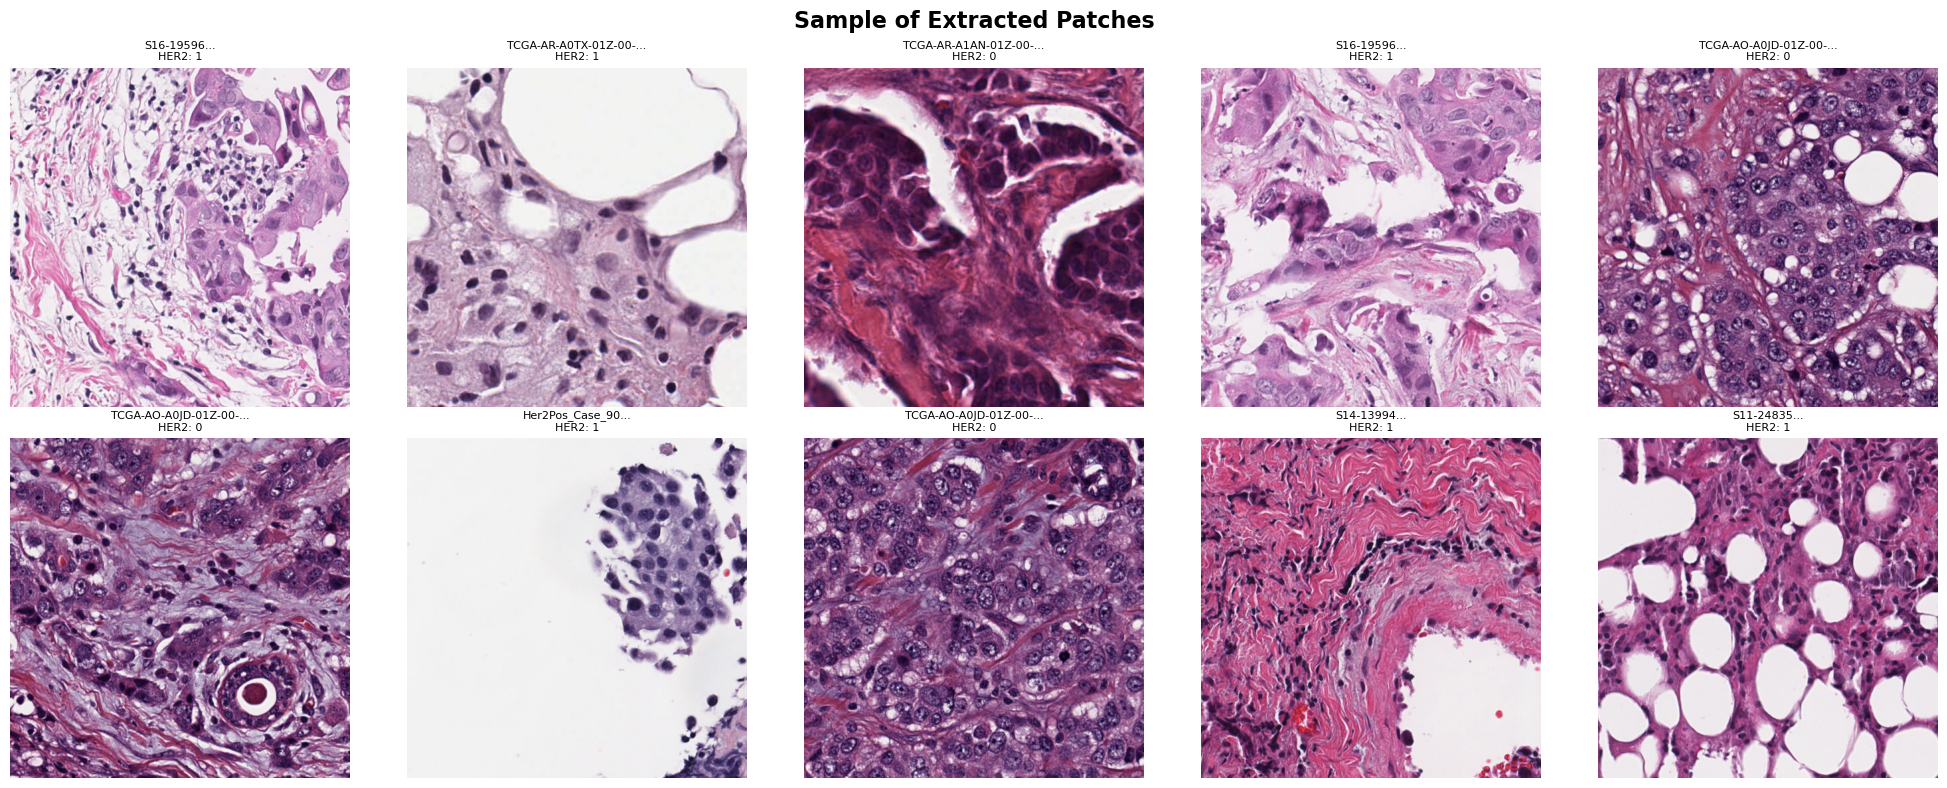

In [6]:
from PIL import Image  # <-- Add this import

# Visualize a sample of extracted patches
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Sample 10 random patches
sample_patches = test_metadata.sample(n=min(10, len(test_metadata)), random_state=42)

for idx, (_, row) in enumerate(sample_patches.iterrows()):
    img = Image.open(row['patch_path'])
    axes[idx].imshow(img)
    axes[idx].set_title(f"{row['slide_id'][:20]}...\nHER2: {row['label']}", fontsize=8)
    axes[idx].axis('off')

plt.suptitle('Sample of Extracted Patches', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Create Dataset from Saved Patches

In [19]:
# Create dataset that loads from saved PNG patches
from torch.utils.data import Dataset
from torchvision import transforms

class PatchImageDataset(Dataset):
    """Dataset that loads patches from saved PNG files."""
    
    def __init__(self, patch_metadata, transform=None):
        self.patch_metadata = patch_metadata
        
        # Default transform: ImageNet normalization
        if transform is None:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transform
    
    def __len__(self):
        return len(self.patch_metadata)
    
    def __getitem__(self, idx):
        row = self.patch_metadata.iloc[idx]
        patch_path = row['patch_path']
        label = int(row['label'])
        
        # Load patch from PNG file
        patch = Image.open(patch_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            patch = self.transform(patch)
        
        return patch, label

# Create dataset and dataloader
test_dataset = PatchImageDataset(
    patch_metadata=test_metadata
)

test_loader = DataLoader(
    test_dataset,
    batch_size=eval_config['batch_size'],
    shuffle=False,  # Keep order for result analysis
    num_workers=eval_config['num_workers'],
    pin_memory=True if eval_config['device'] == 'cuda' else False
)

print(f"Test DataLoader created:")
print(f"  Batches: {len(test_loader)}")
print(f"  Batch size: {eval_config['batch_size']}")
print(f"  Total patches: {len(test_dataset)}")

Test DataLoader created:
  Batches: 0
  Batch size: 32
  Total patches: 0


## 5. Run Inference

In [8]:
all_preds = []
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Evaluating")):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        if device.type == 'cuda':
            with autocast(device_type='cuda', enabled=True):
                logits = model(images)
                probs = torch.softmax(logits, dim=1)
        else:
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
        
        # Store predictions
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Concatenate all batches
all_probs = np.concatenate(all_probs, axis=0)  # Shape: (N, num_classes)
all_preds = np.concatenate(all_preds, axis=0)  # Shape: (N,)
all_labels = np.concatenate(all_labels, axis=0)  # Shape: (N,)

print(f"\nInference completed!")
print(f"  Total predictions: {len(all_preds)}")
print(f"  Predictions shape: {all_preds.shape}")
print(f"  Probabilities shape: {all_probs.shape}")

Evaluating: 100%|██████████| 13/13 [00:08<00:00,  1.48it/s]


Inference completed!
  Total predictions: 400
  Predictions shape: (400,)
  Probabilities shape: (400, 2)


## 6. Calculate Metrics

In [9]:
# Calculate patch-level metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')

# AUC requires probabilities for positive class
auc = roc_auc_score(all_labels, all_probs[:, 1])

print("=" * 60)
print("PATCH-LEVEL METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print("=" * 60)

# Classification report
print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=['HER2-', 'HER2+']))

PATCH-LEVEL METRICS
Accuracy:  0.9625
Precision: 0.9596
Recall:    0.9727
F1 Score:  0.9661
AUC:       0.9837

Classification Report:
              precision    recall  f1-score   support

       HER2-       0.97      0.95      0.96       180
       HER2+       0.96      0.97      0.97       220

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



## 7. Visualizations

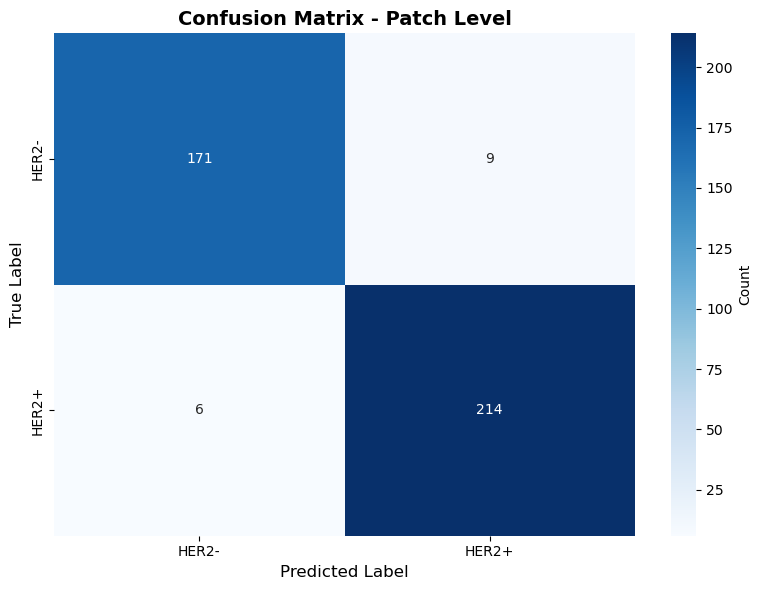


Confusion Matrix:
  True Negatives:  171
  False Positives: 9
  False Negatives: 6
  True Positives:  214


In [10]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['HER2-', 'HER2+'],
            yticklabels=['HER2-', 'HER2+'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Patch Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

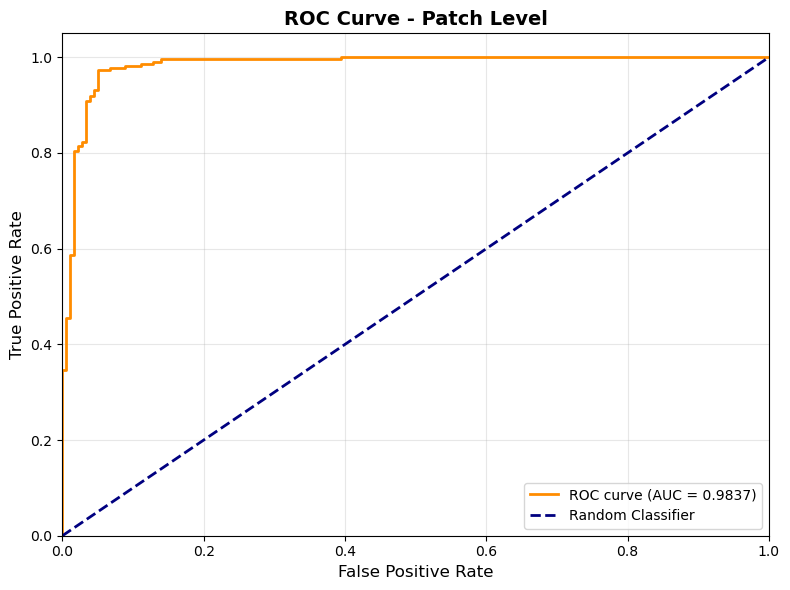

In [11]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Patch Level', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Slide-Level Aggregation (Optional)

In [1]:
# Aggregate patch predictions to slide level
# Add predictions to test metadata
test_metadata['pred_label'] = all_preds
test_metadata['pred_prob_pos'] = all_probs[:, 1]

# Group by slide and aggregate
slide_results = test_metadata.groupby('slide_id').agg({
    'label': 'first',  # Ground truth (same for all patches from one slide)
    'pred_prob_pos': 'mean',  # Average probability across patches
}).reset_index()

# Predict slide label based on average probability
slide_results['pred_label'] = (slide_results['pred_prob_pos'] > 0.5).astype(int)

# Calculate slide-level metrics
slide_accuracy = accuracy_score(slide_results['label'], slide_results['pred_label'])
slide_precision = precision_score(slide_results['label'], slide_results['pred_label'], average='binary')
slide_recall = recall_score(slide_results['label'], slide_results['pred_label'], average='binary')
slide_f1 = f1_score(slide_results['label'], slide_results['pred_label'], average='binary')
slide_auc = roc_auc_score(slide_results['label'], slide_results['pred_prob_pos'])

print("=" * 60)
print("SLIDE-LEVEL METRICS (Averaged Probabilities)")
print("=" * 60)
print(f"Accuracy:  {slide_accuracy:.4f}")
print(f"Precision: {slide_precision:.4f}")
print(f"Recall:    {slide_recall:.4f}")
print(f"F1 Score:  {slide_f1:.4f}")
print(f"AUC:       {slide_auc:.4f}")
print("=" * 60)
print(f"Total slides evaluated: {len(slide_results)}")

NameError: name 'all_preds' is not defined

## 9. Save Results

In [ ]:
import os
from pathlib import Path

# Create output directory
output_dir = Path(eval_config['output_dir'])
output_dir.mkdir(parents=True, exist_ok=True)

# Save patch-level predictions
if eval_config['save_predictions']:
    patch_results_path = output_dir / 'patch_predictions.csv'
    test_metadata.to_csv(patch_results_path, index=False)
    print(f"Saved patch predictions to: {patch_results_path}")

# Save slide-level predictions
slide_results_path = output_dir / 'slide_predictions.csv'
slide_results.to_csv(slide_results_path, index=False)
print(f"Saved slide predictions to: {slide_results_path}")

# Save metrics summary
metrics_summary = {
    'patch_level': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc': float(auc),
    },
    'slide_level': {
        'accuracy': float(slide_accuracy),
        'precision': float(slide_precision),
        'recall': float(slide_recall),
        'f1_score': float(slide_f1),
        'auc': float(slide_auc),
    }
}

import json
metrics_path = output_dir / 'metrics_summary.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print(f"Saved metrics summary to: {metrics_path}")

print(f"\nAll results saved to: {output_dir}")